# Probabilidad y Estadística para la Inteligencia Artificial
## Segundo Examen Parcial

**Docente:** Camilo Argoty  
**Nombre:** Santiago Federico Bettig  
**Código:** a2505

---

In [10]:
# Incluyo las bibliotecas que voy a utilizar para la resolución
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

# Necesito inicializar este complemento para poder
# utilizar la notación simbólica.
sp.init_printing(use_latex='mathjax')

---
## Ejercicio 1:

### Enunciado
![Ejercicio 1](figuras/ejercicio_1.png)
---
### Resolución

#### Conteo de frecuencias observadas

A partir de la muestra contamos las ocurrencias de cada valor:

| Valor | Frecuencia |
|:-----:|:----------:|
| 0 | 3 |
| 1 | 1 |
| 2 | 4 |
| 3 | 2 |

#### Función de verosimilitud

La verosimilitud es el producto de las probabilidades de cada observación:

$$L(\theta) = \prod_{i=1}^{n} p(x_i; \theta) = [\theta]^3 \cdot [2\theta]^1 \cdot \left[\frac{1-3\theta}{3}\right]^4 \cdot \left[\frac{2(1-3\theta)}{3}\right]^2$$

#### Log-verosimilitud

Tomando logaritmo natural para simplificar la optimización:

$$\ell(\theta) = 3\ln(\theta) + \ln(2\theta) + 4\ln\left(\frac{1-3\theta}{3}\right) + 2\ln\left(\frac{2(1-3\theta)}{3}\right)$$

Reordenando:

$$\ell(\theta) = 4\ln(\theta) + 6\ln(1-3\theta) + \text{constantes}$$

#### Condición de primer orden

$$\frac{d\ell}{d\theta} = \frac{4}{\theta} + \frac{6 \cdot (-3)}{1-3\theta} = 0$$

$$\frac{4}{\theta} = \frac{18}{1-3\theta}$$

$$4(1-3\theta) = 18\theta \implies 4 - 12\theta = 18\theta \implies 4 = 30\theta$$

$$\boxed{\hat{\theta}_{MLE} = \frac{4}{30} = \frac{2}{15} \approx 0.1\overline{3}}$$

In [2]:
# Voy a utilizar símbolos para mostrar las ecuaciones, 
# por lo que defino theta
theta = sp.Symbol('theta', positive=True)

# Frecuencias observadas: n0=3, n1=1, n2=4, n3=2
n0, n1, n2, n3 = 3, 1, 4, 2

# Probabilidades según la tabla
p0 = theta
p1 = 2 * theta
p2 = (1 - 3*theta) / 3
p3 = 2*(1 - 3*theta) / 3

# Verifico que la suma de las probabilidades
# sea igual a cero
suma = sp.simplify(p0 + p1 + p2 + p3)
print(f"Suma de probabilidades: {suma}  ✓")

# Calculo el logaritmo de la verosimilitud
log_L = (n0 * sp.log(p0) + n1 * sp.log(p1)
         + n2 * sp.log(p2) + n3 * sp.log(p3))

# Derivo e igualo a cero.
d_log_L = sp.diff(log_L, theta)
theta_hat = sp.solve(d_log_L, theta)[0]

print(f"\nDerivada de la log-verosimilitud:")
sp.pprint(d_log_L)
print(f"\nMLE de θ: {theta_hat} = {float(theta_hat):.6f}")

Suma de probabilidades: 1  ✓

Derivada de la log-verosimilitud:
      4          4      4
- ───────── - ─────── + ─
  2/3 - 2⋅θ   1/3 - θ   θ

MLE de θ: 2/15 = 0.133333


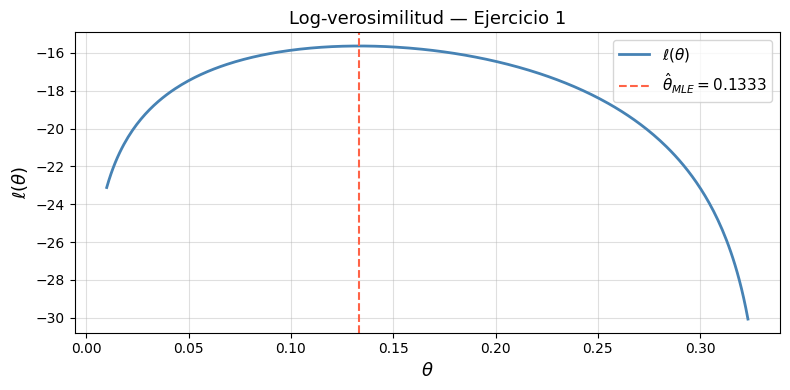


Probabilidades bajo θ_hat = 0.1333:
  p(X=0) = θ          = 0.1333
  p(X=1) = 2θ         = 0.2667
  p(X=2) = (1-3θ)/3   = 0.2000
  p(X=3) = 2(1-3θ)/3  = 0.4000
  Suma   = 1.0000


In [3]:
# Verificación numérica: gráfico de la log-verosimilitud
theta_vals = np.linspace(0.01, 1/3 - 0.01, 300)  # θ ∈ (0, 1/3) para que p2, p3 > 0

log_L_num = (n0 * np.log(theta_vals)
             + n1 * np.log(2 * theta_vals)
             + n2 * np.log((1 - 3*theta_vals) / 3)
             + n3 * np.log(2*(1 - 3*theta_vals) / 3))

theta_hat_num = float(theta_hat)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(theta_vals, log_L_num, color='steelblue', linewidth=2, label=r'$\ell(\theta)$')
ax.axvline(theta_hat_num, color='tomato', linestyle='--',
           label=rf'$\hat{{\theta}}_{{MLE}} = {theta_hat_num:.4f}$')
ax.set_xlabel(r'$\theta$', fontsize=13)
ax.set_ylabel(r'$\ell(\theta)$', fontsize=13)
ax.set_title('Log-verosimilitud — Ejercicio 1', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nProbabilidades bajo θ_hat = {theta_hat_num:.4f}:")
print(f"  p(X=0) = θ          = {theta_hat_num:.4f}")
print(f"  p(X=1) = 2θ         = {2*theta_hat_num:.4f}")
print(f"  p(X=2) = (1-3θ)/3   = {(1-3*theta_hat_num)/3:.4f}")
print(f"  p(X=3) = 2(1-3θ)/3  = {2*(1-3*theta_hat_num)/3:.4f}")
print(f"  Suma   = {theta_hat_num + 2*theta_hat_num + (1-3*theta_hat_num)/3 + 2*(1-3*theta_hat_num)/3:.4f}")

---
## Ejercicio 2:

### Enunciado
![Ejercicio 2](figuras/ejercicio_2.png)
---
### Resolución

#### Sistema de ecuaciones normales

El estimador de mínimos cuadrados minimiza $S = \sum_{i=1}^n (y_i - a - b x_i - c x_i^2)^2$.

Las condiciones de primer orden $\partial S / \partial a = 0$, $\partial S / \partial b = 0$, $\partial S / \partial c = 0$ dan el **sistema de ecuaciones normales**:

$$\begin{pmatrix} n & \sum x_i & \sum x_i^2 \\ \sum x_i & \sum x_i^2 & \sum x_i^3 \\ \sum x_i^2 & \sum x_i^3 & \sum x_i^4 \end{pmatrix} \begin{pmatrix} a \\ b \\ c \end{pmatrix} = \begin{pmatrix} \sum y_i \\ \sum x_i y_i \\ \sum x_i^2 y_i \end{pmatrix}$$

En forma compacta: $X^T X \boldsymbol{\beta} = X^T \mathbf{y}$, con solución $\hat{\boldsymbol{\beta}} = (X^T X)^{-1} X^T \mathbf{y}$.

In [ ]:
X_data = np.array([1, 5, 11, 19, 20], dtype=float)
Y_data = np.array([2, 33, 83, 317, 478], dtype=float)
n = len(X_data)

# Matriz de diseño [1, x, x²]
A = np.column_stack([np.ones(n), X_data, X_data**2])

print("Matriz de diseño A:")
print(A)

Matriz de diseño A:
[[  1.   1.   1.]
 [  1.   5.  25.]
 [  1.  11. 121.]
 [  1.  19. 361.]
 [  1.  20. 400.]]


In [ ]:
# Debo buscar la solución de β̂ = (AᵀA)⁻¹ Aᵀy

# Obtengo (AᵀA)
AtA = A.T @ A
# Obtengo Aᵀy
Aty = A.T @ Y_data

# Imprimo los resultados
print("Matriz AᵀA (ecuaciones normales):")
print(AtA)
print("\nVector Aᵀy:")
print(Aty)

beta_hat = np.linalg.solve(AtA, Aty)
a_hat, b_hat, c_hat = beta_hat

print(f"\n── Estimadores MLS ─────────────────")
print(f"  â = {a_hat:.6f}")
print(f"  b̂ = {b_hat:.6f}")
print(f"  ĉ = {c_hat:.6f}")
print(f"\nModelo ajustado: Ŷ = {a_hat:.4f} + {b_hat:.4f}·X + {c_hat:.4f}·X²")

Matriz AᵀA (ecuaciones normales):
[[5.00000e+00 5.60000e+01 9.08000e+02]
 [5.60000e+01 9.08000e+02 1.63160e+04]
 [9.08000e+02 1.63160e+04 3.05588e+05]]

Vector Aᵀy:
[   913.  16663. 316507.]

── Estimadores MLS ─────────────────
  â = 26.978745
  b̂ = -11.908360
  ĉ = 1.591382

Modelo ajustado: Ŷ = 26.9787 + -11.9084·X + 1.5914·X²


Verificación con np.polyfit: [c, b, a] = [  1.59138155 -11.90836026  26.97874538]
  â = 26.978745, b̂ = -11.908360, ĉ = 1.591382

Y observados : [  2.  33.  83. 317. 478.]
Ŷ ajustados  : [ 16.662   7.221  88.544 375.209 425.364]
Residuos     : [-14.662  25.779  -5.544 -58.209  52.636]
SSE = 7069.0121,  R² = 0.958476


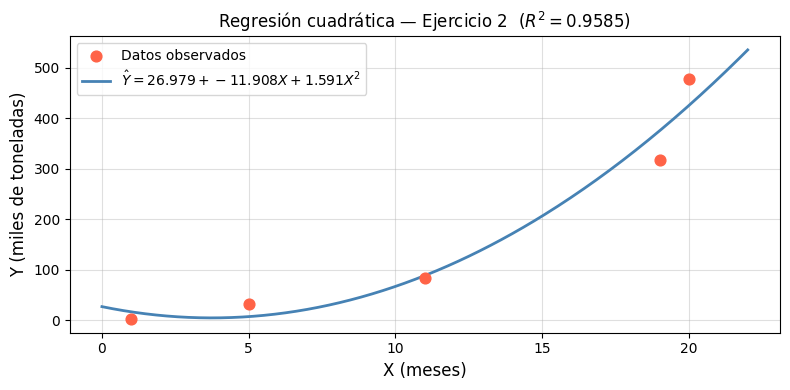

In [ ]:
# Verificación con numpy.polyfit (ajuste polinomial grado 2)
coefs_np = np.polyfit(X_data, Y_data, 2)  # devuelve [c, b, a]
print("Verificación con np.polyfit: [c, b, a] =", coefs_np)
print(f"  â = {coefs_np[2]:.6f}, b̂ = {coefs_np[1]:.6f}, ĉ = {coefs_np[0]:.6f}")

# Valores ajustados y residuos
Y_hat = a_hat + b_hat * X_data + c_hat * X_data**2
residuals = Y_data - Y_hat
SSE = np.sum(residuals**2)
SST = np.sum((Y_data - Y_data.mean())**2)
R2 = 1 - SSE / SST

print(f"\nY observados : {Y_data}")
print(f"Ŷ ajustados  : {Y_hat.round(3)}")
print(f"Residuos     : {residuals.round(3)}")
print(f"SSE = {SSE:.4f},  R² = {R2:.6f}")

# Gráfico
X_plot = np.linspace(0, 22, 300)
Y_plot = a_hat + b_hat * X_plot + c_hat * X_plot**2

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X_data, Y_data, color='tomato', zorder=5, s=60, label='Datos observados')
ax.plot(X_plot, Y_plot, color='steelblue', linewidth=2,
        label=rf'$\hat{{Y}} = {a_hat:.3f} + {b_hat:.3f}X + {c_hat:.3f}X^2$')
ax.set_xlabel('X (meses)', fontsize=12)
ax.set_ylabel('Y (miles de toneladas)', fontsize=12)
ax.set_title(f'Regresión cuadrática — Ejercicio 2  ($R^2 = {R2:.4f}$)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## Ejercicio 3:

### Enunciado
![Ejercicio 3](figuras/ejercicio_3.png)
---
### Resolución

#### Prior

$$p \sim \text{Beta}(\alpha_0, \beta_0) = \text{Beta}(1, 4)$$

$$f_{prior}(p) = \frac{p^{\alpha_0 - 1}(1-p)^{\beta_0 - 1}}{B(\alpha_0, \beta_0)} \propto p^{0}(1-p)^{3}$$

#### Verosimilitud: modelo Binomial

Elegí la Binomial porque el problema cumple exactamente sus supuestos:

 - Número fijo de ensayos: hay n=9 clientes, cada uno es un "ensayo".
 - Resultado binario: cada cliente o está en mora o no lo está.
 - Independencia: se asume que el comportamiento de pago de un cliente no afecta al de los demás.
 - Probabilidad constante: todos los clientes tienen la misma probabilidad p de caer en mora, que es justamente el parámetro que querés estimar

Con $n = 9$ ensayos y $k = 0$ éxitos (moras):

$$L(p \mid k, n) = \binom{n}{k} p^k (1-p)^{n-k} \propto p^0 (1-p)^9$$

#### Posterior: conjugada Beta/Binomial

La familia Beta es **conjugada** de la Binomial. El posterior es:

$$f_{post}(p) \propto f_{prior}(p) \cdot L(p) \propto p^{\alpha_0 + k - 1}(1-p)^{\beta_0 + n - k - 1}$$

$$\boxed{p \mid \text{datos} \sim \text{Beta}(\alpha_{post}, \beta_{post})}$$

con:

$$\alpha_{post} = \alpha_0 + k = 1 + 0 = 1$$

$$\beta_{post} = \beta_0 + (n - k) = 4 + 9 = 13$$

#### Media y varianza del posterior

Para $\text{Beta}(\alpha, \beta)$:

$$\mathbb{E}[p] = \frac{\alpha_{post}}{\alpha_{post} + \beta_{post}} = \frac{1}{14} \approx 0.0714$$

$$\text{Var}[p] = \frac{\alpha_{post}\,\beta_{post}}{(\alpha_{post}+\beta_{post})^2\,(\alpha_{post}+\beta_{post}+1)} = \frac{1 \cdot 13}{14^2 \cdot 15} = \frac{13}{2940} \approx 0.00442$$

In [ ]:
# Parámetros del problema
alpha_0 = 1      # prior α
beta_0  = 4      # prior β
n_obs   = 9      # clientes
k_mora  = 0      # en mora

# Posterior
alpha_post = alpha_0 + k_mora
beta_post  = beta_0  + (n_obs - k_mora)

print(f"Prior:     Beta({alpha_0}, {beta_0})")
print(f"Datos:     n = {n_obs}, k = {k_mora}")
print(f"Posterior: Beta({alpha_post}, {beta_post})")

# Media y varianza
mean_post = alpha_post / (alpha_post + beta_post)
var_post  = (alpha_post * beta_post) / ((alpha_post + beta_post)**2 * (alpha_post + beta_post + 1))

print(f"\nMedia posterior   E[p] = {alpha_post}/{alpha_post+beta_post} = {mean_post:.6f}")
print(f"Varianza posterior Var[p] = {alpha_post}·{beta_post}/({alpha_post+beta_post}²·{alpha_post+beta_post+1})"
      f" = {alpha_post*beta_post}/{(alpha_post+beta_post)**2*(alpha_post+beta_post+1)} ≈ {var_post:.6f}")

Prior:     Beta(1, 4)
Datos:     n = 9, k = 0
Posterior: Beta(1, 13)

Media posterior   E[p] = 1/14 = 0.071429
Varianza posterior Var[p] = 1·13/(14²·15) = 13/2940 ≈ 0.004422


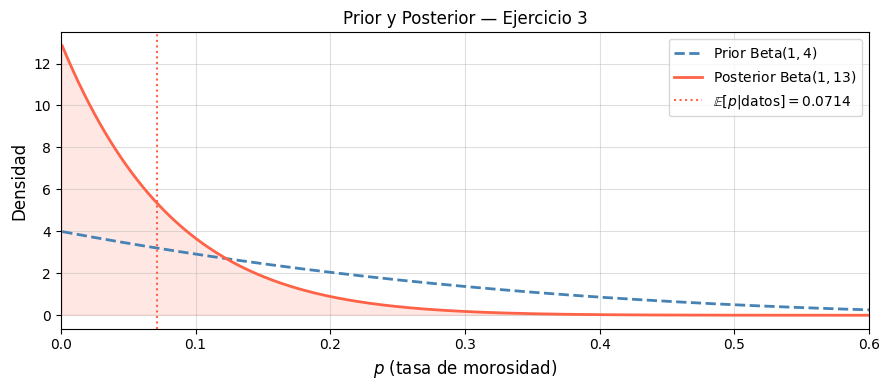


Verificación scipy.stats.beta(1, 13):
  Media    = 0.071429
  Varianza = 0.004422


In [9]:
# Visualización: prior vs posterior
p_vals = np.linspace(0.001, 0.999, 500)

prior_pdf     = beta_dist.pdf(p_vals, alpha_0, beta_0)
posterior_pdf = beta_dist.pdf(p_vals, alpha_post, beta_post)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(p_vals, prior_pdf, color='steelblue', linestyle='--', linewidth=2,
        label=rf'Prior $\text{{Beta}}({alpha_0},{beta_0})$')
ax.plot(p_vals, posterior_pdf, color='tomato', linewidth=2,
        label=rf'Posterior $\text{{Beta}}({alpha_post},{beta_post})$')
ax.axvline(mean_post, color='tomato', linestyle=':', linewidth=1.5,
           label=rf'$\mathbb{{E}}[p|\text{{datos}}] = {mean_post:.4f}$')

ax.fill_between(p_vals, posterior_pdf, alpha=0.15, color='tomato')

ax.set_xlabel('$p$ (tasa de morosidad)', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.set_title('Prior y Posterior — Ejercicio 3', fontsize=12)
ax.set_xlim(0, 0.6)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Verificación con scipy.stats
print(f"\nVerificación scipy.stats.beta({alpha_post}, {beta_post}):")
print(f"  Media    = {beta_dist.mean(alpha_post, beta_post):.6f}")
print(f"  Varianza = {beta_dist.var(alpha_post, beta_post):.6f}")